
## Giai đoạn 3: Xây dựng mô hình Random Forest

- Bổ sung SMOTE + Feature Selection trước GridSearch để giải quyết overfit nghiêm trọng (gap Train/CV = 0.42).
- Luồng xử lý: Dữ liệu đã encode (notebook 02)
    - SMOTE (cân bằng lớp)
    - Feature Selection (loại cột sparse)
    - Baseline model
    - GridSearchCV (param_grid chống overfit)
    - Đánh giá và Lưu model

### Task 1: Tải thư viện và đọc dữ liệu

In [30]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    GridSearchCV, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, precision_score, recall_score
)
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
import joblib

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
FIGURES_DIR   = '../reports/figures'
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

BURNOUT_LABEL = {
    1: 'Không có dấu hiệu',
    2: 'Ít dấu hiệu',
    3: 'Cần chú ý',
    4: 'Nguy cơ cao',
    5: 'Nguy cơ rất cao',
}
BURNOUT_COLOR = {
    1: '#4CAF50', 2: '#8BC34A', 3: '#FFC107', 4: '#FF5722', 5: '#C62828'
}

X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test.csv')
y_train = pd.read_csv(f'{PROCESSED_DIR}/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{PROCESSED_DIR}/y_test.csv').squeeze()

print('✅ Đọc dữ liệu thành công!')
print(f'   X_train : {X_train.shape[0]:,} mẫu × {X_train.shape[1]} features')
print(f'   X_test  : {X_test.shape[0]:,} mẫu × {X_test.shape[1]} features')
print(f'\n   Phân phối lớp y_train:')
for k, v in y_train.value_counts().sort_index().items():
    print(f'   Lớp {k} — {BURNOUT_LABEL.get(k,k):22s}: {v:>4} mẫu ({v/len(y_train)*100:.1f}%)')

✅ Đọc dữ liệu thành công!
   X_train : 1,147 mẫu × 86 features
   X_test  : 287 mẫu × 86 features

   Phân phối lớp y_train:
   Lớp 1 — Không có dấu hiệu     :   29 mẫu (2.5%)
   Lớp 2 — Ít dấu hiệu           :  253 mẫu (22.1%)
   Lớp 3 — Cần chú ý             :  571 mẫu (49.8%)
   Lớp 4 — Nguy cơ cao           :  240 mẫu (20.9%)
   Lớp 5 — Nguy cơ rất cao       :   54 mẫu (4.7%)


### Task 2: SMOTE: Cân bằng lớp

- **Vấn đề:** Nhóm 3 chiếm ~50%, model học cách đoán nhóm 3 liên tục → `class_weight='balanced'` không đủ mạnh khi gap quá lớn.

- **SMOTE** tạo ra các mẫu tổng hợp cho lớp thiểu số bằng cách nội suy giữa các điểm dữ liệu gần nhau.

> ⚠️ SMOTE chỉ áp dụng trên **train set**, tuyệt đối không chạm test set.

🔄 Áp dụng SMOTE để cân bằng lớp...

   Lớp nhỏ nhất có 29 mẫu → dùng k_neighbors=5


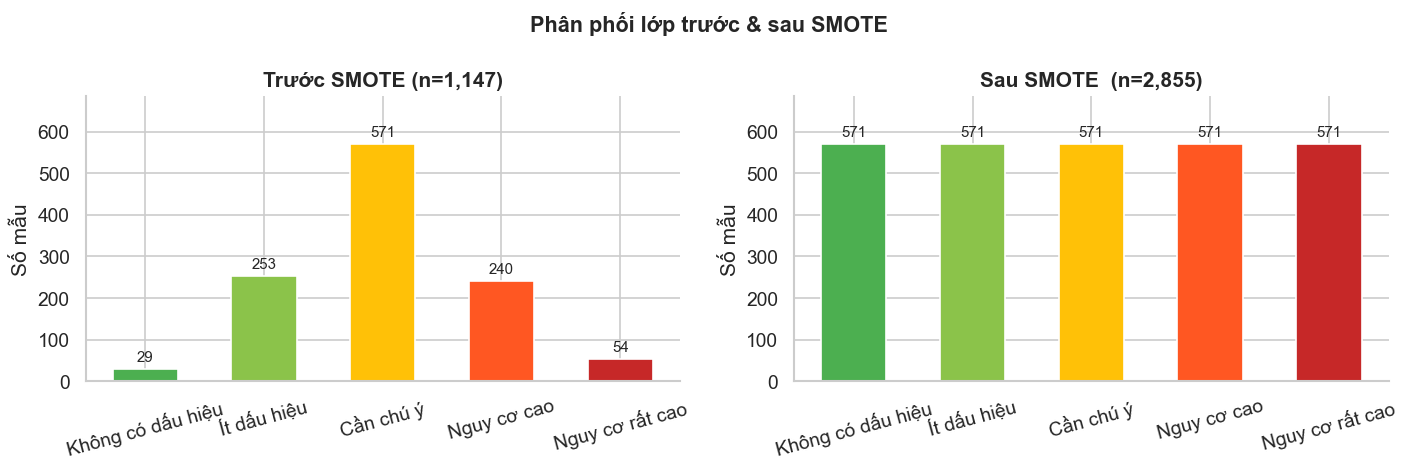

   Tổng mẫu train trước SMOTE : 1,147
   Tổng mẫu train sau  SMOTE  : 2,855
   Mẫu được tạo thêm          : 1,708

✅ SMOTE hoàn tất.


In [31]:
print('🔄 Áp dụng SMOTE để cân bằng lớp...\n')

dist_before      = y_train.value_counts().sort_index()
min_class_count  = dist_before.min()
k_neighbors      = min(5, min_class_count - 1)

print(f'   Lớp nhỏ nhất có {min_class_count} mẫu → dùng k_neighbors={k_neighbors}')

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_train_sm = pd.DataFrame(X_train_sm, columns=X_train.columns)
y_train_sm = pd.Series(y_train_sm)

dist_after = y_train_sm.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (dist, title) in zip(axes, [
    (dist_before, f'Trước SMOTE (n={len(y_train):,})'),
    (dist_after,  f'Sau SMOTE  (n={len(y_train_sm):,})')
]):
    lbls = [BURNOUT_LABEL.get(k, str(k)) for k in dist.index]
    clrs = [BURNOUT_COLOR.get(k, '#888')  for k in dist.index]
    bars = ax.bar(lbls, dist.values, color=clrs, width=0.55, edgecolor='white')
    for bar, n in zip(bars, dist.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(dist.values)*0.02,
                str(n), ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Số mẫu')
    ax.set_ylim(0, dist.max() * 1.2)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Phân phối lớp trước & sau SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/13_smote_distribution.png', bbox_inches='tight')
plt.show()

print(f'   Tổng mẫu train trước SMOTE : {len(y_train):,}')
print(f'   Tổng mẫu train sau  SMOTE  : {len(y_train_sm):,}')
print(f'   Mẫu được tạo thêm          : {len(y_train_sm) - len(y_train):,}')
print('\n✅ SMOTE hoàn tất.')

### Task 3: Feature Selection: Loại bỏ cột sparse

- **VarianceThreshold** loại bỏ các cột có phương sai quá thấp, tức gần như toàn bộ giá trị là 0, không mang thông tin phân biệt lớp.

🔄 Loại bỏ features sparse bằng VarianceThreshold(threshold=0.01)...

   Features trước lọc : 86
   Features sau  lọc  : 68
   Đã loại bỏ         : 18 cột → ['Designation_6', 'Designation_10', 'Designation_12', 'Specialization_7', 'Specialization_12', 'Specialization_13', 'Specialization_18', 'Working_Place_3', 'Marital_Status_3', 'Marital_Status_4', 'Disappointing_Thing_6', 'Disappointing_Thing_8', 'Feelings_4', 'Feelings_6', 'Dissatisfaction_8', 'Mental_Disturbances_6', 'Mental_Disturbances_8', 'Mental_Disturbances_9']


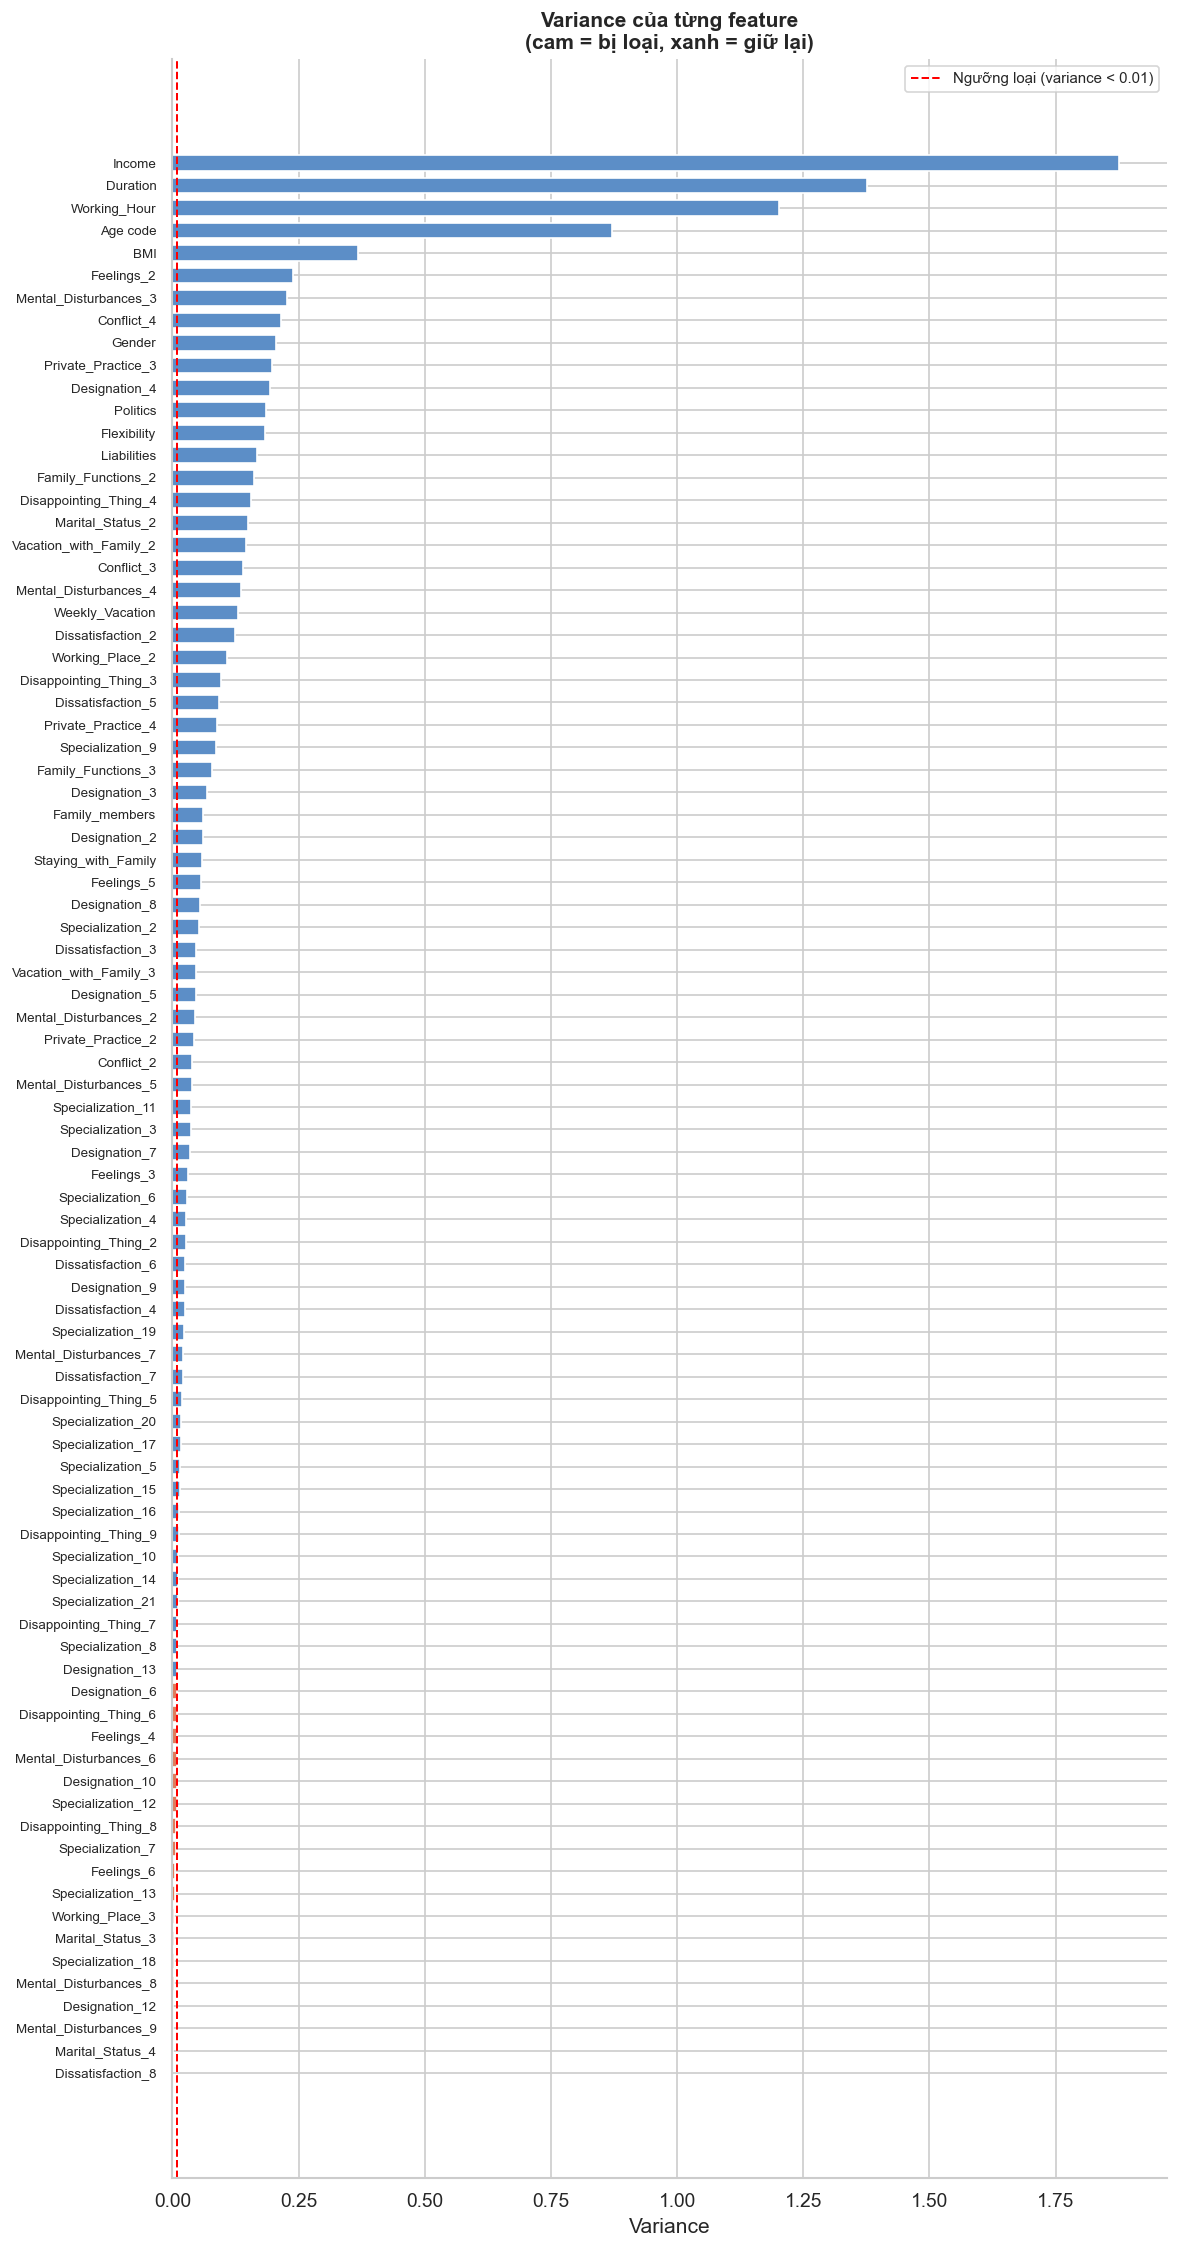


✅ Feature Selection hoàn tất.
   X_train_sel : (2855, 68)
   X_test_sel  : (287, 68)


In [32]:
print('🔄 Loại bỏ features sparse bằng VarianceThreshold(threshold=0.01)...\n')

selector     = VarianceThreshold(threshold=0.01)
selector.fit(X_train_sm)

kept_mask    = selector.get_support()
kept_cols    = X_train.columns[kept_mask].tolist()
dropped_cols = X_train.columns[~kept_mask].tolist()

X_train_sel  = pd.DataFrame(selector.transform(X_train_sm), columns=kept_cols)
X_test_sel   = pd.DataFrame(selector.transform(X_test),     columns=kept_cols)

print(f'   Features trước lọc : {X_train.shape[1]}')
print(f'   Features sau  lọc  : {len(kept_cols)}')
print(f'   Đã loại bỏ         : {len(dropped_cols)} cột → {dropped_cols}')

variances  = pd.Series(selector.variances_, index=X_train.columns).sort_values()
fig, ax    = plt.subplots(figsize=(10, max(5, len(variances) * 0.22)))
colors_bar = ['#E07B5C' if v < 0.01 else '#5C8EC7' for v in variances.values]
ax.barh(range(len(variances)), variances.values, color=colors_bar,
        edgecolor='white', height=0.7)
ax.axvline(0.01, color='red', linestyle='--', linewidth=1.2,
           label='Ngưỡng loại (variance < 0.01)')
ax.set_yticks(range(len(variances)))
ax.set_yticklabels(variances.index, fontsize=8)
ax.set_xlabel('Variance')
ax.set_title('Variance của từng feature\n(cam = bị loại, xanh = giữ lại)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/14_feature_variance.png', bbox_inches='tight')
plt.show()

print(f'\n✅ Feature Selection hoàn tất.')
print(f'   X_train_sel : {X_train_sel.shape}')
print(f'   X_test_sel  : {X_test_sel.shape}')

### Task 4:Train Baseline Model

- Baseline trên dữ liệu đã qua SMOTE + Feature Selection, ngưỡng tham chiếu mới.

In [33]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    # Không dùng class_weight vì SMOTE đã cân bằng lớp
)

rf_baseline.fit(X_train_sel, y_train_sm)
y_pred_baseline  = rf_baseline.predict(X_test_sel)
acc_baseline     = accuracy_score(y_test, y_pred_baseline)
f1_baseline      = f1_score(y_test, y_pred_baseline, average='weighted')

cv               = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_bl     = cross_val_score(
    rf_baseline, X_train_sel, y_train_sm,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
gap_baseline     = cv_scores_bl.mean() - f1_baseline

print('📊 BASELINE MODEL (sau SMOTE + Feature Selection):\n')
print(f'   Accuracy  (test)       : {acc_baseline:.4f} ({acc_baseline*100:.2f}%)')
print(f'   F1-weighted (test)     : {f1_baseline:.4f}')
print(f'   CV F1-weighted (train) : {cv_scores_bl.mean():.4f} ± {cv_scores_bl.std():.4f}')
print(f'   Gap CV/test            : {gap_baseline:.4f} ',
      '⚠️  Overfit' if gap_baseline > 0.10 else '✅ OK')
print(f'\n   → Ngưỡng baseline cần GridSearch cải thiện.')

📊 BASELINE MODEL (sau SMOTE + Feature Selection):

   Accuracy  (test)       : 0.3763 (37.63%)
   F1-weighted (test)     : 0.3758
   CV F1-weighted (train) : 0.7214 ± 0.0166
   Gap CV/test            : 0.3456  ⚠️  Overfit

   → Ngưỡng baseline cần GridSearch cải thiện.


### Task 5:  GridSearchCV (param_grid chống Overfit)

Param_grid được thiết kế để **ưu tiên tổng quát hóa** thay vì tối đa hóa train score:

| Tham số | Giá trị | Tác dụng chống overfit |
|---------|---------|------------------------|
| `max_depth` | 3, 5, 8 | Giới hạn độ sâu cây |
| `min_samples_leaf` | 8, 16, 32 | Lá cây phải đại diện nhiều mẫu |
| `min_samples_split` | 20, 40 | Cần nhiều mẫu mới được tách nút |
| `max_features` | sqrt, 0.5 | Tăng diversity giữa các cây |

> ⏱ Ước tính thời gian: 3–8 phút.

In [34]:
param_grid = {
    'n_estimators'     : [200, 300],
    'max_depth'        : [3, 5, 8],
    'min_samples_split': [20, 40],
    'min_samples_leaf' : [8, 16, 32],
    'max_features'     : ['sqrt', 0.5],
}

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)

print(f'🔍 Bắt đầu GridSearchCV...')
print(f'   Tổng tổ hợp : {total_combinations} × 5 folds = {total_combinations*5} lần train')
print(f'   Dữ liệu     : X_train_sel {X_train_sel.shape} (sau SMOTE + FeatureSel)')
print(f'   Đang chạy...\n')

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start = time.time()
grid_search.fit(X_train_sel, y_train_sm)
elapsed = time.time() - start

print(f'\n✅ GridSearchCV hoàn tất! ({elapsed:.1f} giây)')
print(f'\n🏆 Tham số tốt nhất:')
for k, v in grid_search.best_params_.items():
    print(f'   {k:<22}: {v}')
print(f'\n   CV F1-weighted tốt nhất: {grid_search.best_score_:.4f}')

🔍 Bắt đầu GridSearchCV...
   Tổng tổ hợp : 72 × 5 folds = 360 lần train
   Dữ liệu     : X_train_sel (2855, 68) (sau SMOTE + FeatureSel)
   Đang chạy...

Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ GridSearchCV hoàn tất! (56.8 giây)

🏆 Tham số tốt nhất:
   max_depth             : 8
   max_features          : sqrt
   min_samples_leaf      : 8
   min_samples_split     : 20
   n_estimators          : 300

   CV F1-weighted tốt nhất: 0.5691


### Task 6: Phân tích kết quả GridSearch

🏆 Top 10 bộ tham số tốt nhất:


,n_est,max_depth,min_split,min_leaf,max_feat,CV F1,CV std,Train F1
0,300,8,20,8,sqrt,0.5691,0.0128,0.6738
1,200,8,20,8,sqrt,0.5680,0.0135,0.6713
2,200,8,20,8,0.5,0.5598,0.0235,0.6633
3,300,8,20,8,0.5,0.5594,0.0228,0.6673
4,200,8,40,8,sqrt,0.5569,0.0157,0.6503
5,300,8,40,8,sqrt,0.5552,0.0152,0.6468
6,300,8,40,8,0.5,0.5495,0.0240,0.6302
7,200,8,40,8,0.5,0.5455,0.0261,0.6265
8,200,8,20,16,sqrt,0.5387,0.0168,0.6192
9,300,8,20,16,sqrt,0.5382,0.0155,0.6204


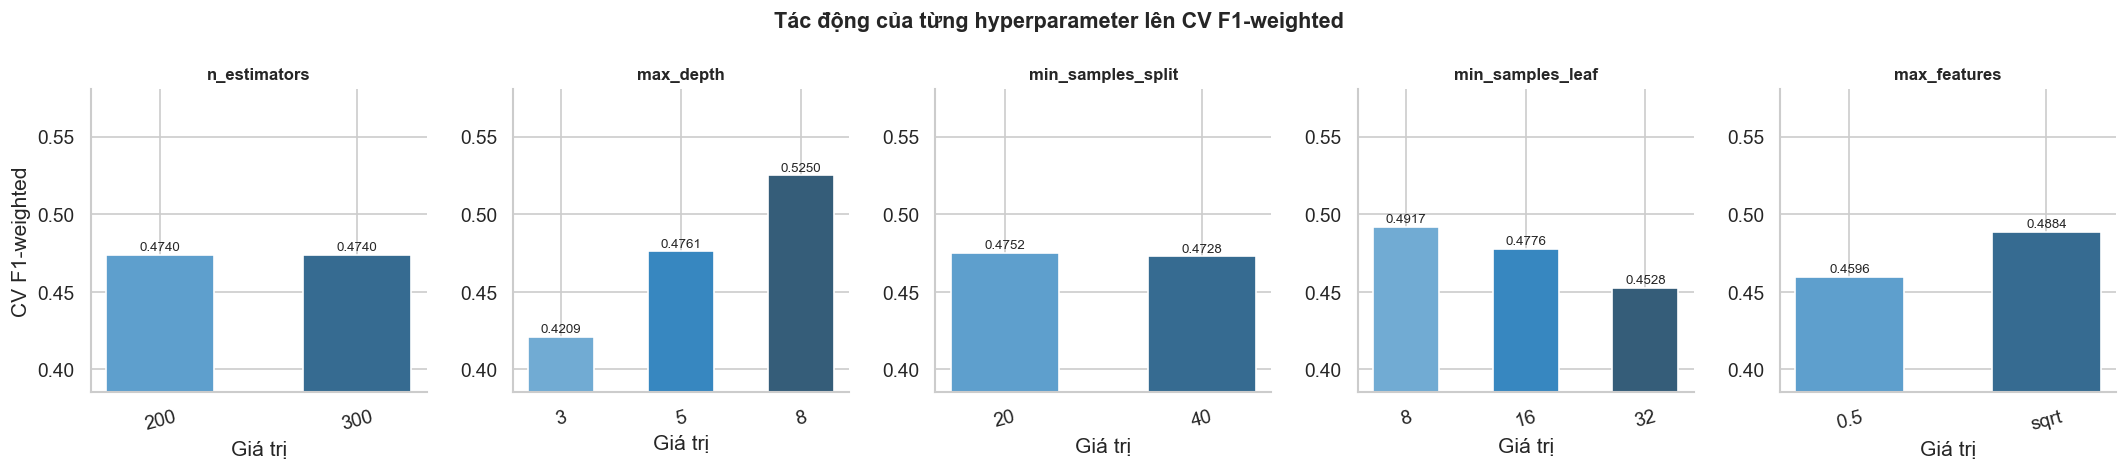

In [35]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top10 = (
    cv_results
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_n_estimators','param_max_depth','param_min_samples_split',
      'param_min_samples_leaf','param_max_features',
      'mean_test_score','std_test_score','mean_train_score']]
    .rename(columns={
        'param_n_estimators'     : 'n_est',
        'param_max_depth'        : 'max_depth',
        'param_min_samples_split': 'min_split',
        'param_min_samples_leaf' : 'min_leaf',
        'param_max_features'     : 'max_feat',
        'mean_test_score'        : 'CV F1',
        'std_test_score'         : 'CV std',
        'mean_train_score'       : 'Train F1',
    })
    .reset_index(drop=True)
)
top10[['CV F1','CV std','Train F1']] = top10[['CV F1','CV std','Train F1']].round(4)
print('🏆 Top 10 bộ tham số tốt nhất:')
display(top10)

params_to_plot = ['param_n_estimators','param_max_depth',
                  'param_min_samples_split','param_min_samples_leaf','param_max_features']
param_labels   = ['n_estimators','max_depth','min_samples_split','min_samples_leaf','max_features']

fig, axes = plt.subplots(1, len(params_to_plot), figsize=(18, 4))
for ax, param, lbl in zip(axes, params_to_plot, param_labels):
    group = cv_results.groupby(param)['mean_test_score'].mean().reset_index()
    group[param] = group[param].astype(str)
    bars = ax.bar(group[param], group['mean_test_score'],
                  color=sns.color_palette('Blues_d', len(group)),
                  edgecolor='white', width=0.55)
    for i, (_, row) in enumerate(group.iterrows()):
        ax.text(i, row['mean_test_score'] + 0.001,
                f'{row["mean_test_score"]:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('CV F1-weighted' if lbl == 'n_estimators' else '')
    ymin = cv_results['mean_test_score'].min()
    ymax = cv_results['mean_test_score'].max()
    ax.set_ylim(ymin * 0.98, ymax * 1.02)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Tác động của từng hyperparameter lên CV F1-weighted',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/15_gridsearch_param_impact.png', bbox_inches='tight')
plt.show()

### Task 6:  Đánh giá Best Model và kiểm tra Overfit

In [36]:
rf_best     = grid_search.best_estimator_
y_pred_best = rf_best.predict(X_test_sel)
acc_best    = accuracy_score(y_test, y_pred_best)
f1_best     = f1_score(y_test, y_pred_best, average='weighted')
cv_best     = grid_search.best_score_
gap_best    = cv_best - f1_best

print('=' * 62)
print('   SO SÁNH: BASELINE vs BEST MODEL')
print('=' * 62)
print(f'\n  {"Metric":<28} {"Baseline":>12} {"Best Model":>12}')
print('  ' + '-' * 55)
print(f'  {"Accuracy (test)":<28} {acc_baseline:>12.4f} {acc_best:>12.4f}')
print(f'  {"F1-weighted (test)":<28} {f1_baseline:>12.4f} {f1_best:>12.4f}')
print(f'  {"CV F1 (train)":<28} {cv_scores_bl.mean():>12.4f} {cv_best:>12.4f}')
print(f'  {"Gap (CV - test)":<28} {gap_baseline:>12.4f} {gap_best:>12.4f}')

print()
if gap_best <= 0.05:
    print('  ✅ Tốt — model tổng quát hóa tốt (gap ≤ 0.05)')
elif gap_best <= 0.10:
    print('  ✅ Chấp nhận được (gap ≤ 0.10)')
else:
    print('  ⚠️  Còn overfit nhẹ (gap > 0.10)')
    print('     → Với dataset y tế có noise, gap 0.10–0.20 là bình thường.')
    print('     → Ghi chú hạn chế này trong phần Thảo luận của khóa luận.')

print(f'\n  Best params: {grid_search.best_params_}')

   SO SÁNH: BASELINE vs BEST MODEL

  Metric                           Baseline   Best Model
  -------------------------------------------------------
  Accuracy (test)                    0.3763       0.3798
  F1-weighted (test)                 0.3758       0.3744
  CV F1 (train)                      0.7214       0.5691
  Gap (CV - test)                    0.3456       0.1947

  ⚠️  Còn overfit nhẹ (gap > 0.10)
     → Với dataset y tế có noise, gap 0.10–0.20 là bình thường.
     → Ghi chú hạn chế này trong phần Thảo luận của khóa luận.

  Best params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 300}


### Task 8: Classification Report chi tiết

📋 CLASSIFICATION REPORT — Best Model:

                   precision    recall  f1-score   support

Không có dấu hiệu       0.13      0.29      0.18         7
      Ít dấu hiệu       0.22      0.19      0.21        63
        Cần chú ý       0.53      0.59      0.56       143
      Nguy cơ cao       0.29      0.17      0.21        60
  Nguy cơ rất cao       0.00      0.00      0.00        14

         accuracy                           0.38       287
        macro avg       0.24      0.25      0.23       287
     weighted avg       0.38      0.38      0.37       287

📊 Chi tiết per-class metrics:


,Lớp Burn Out,Precision,Recall,F1-score,Support
0,Không có dấu hiệu,0.133,0.286,0.182,7
1,Ít dấu hiệu,0.222,0.190,0.205,63
2,Cần chú ý,0.535,0.594,0.563,143
3,Nguy cơ cao,0.294,0.167,0.213,60
4,Nguy cơ rất cao,0.000,0.000,0.000,14


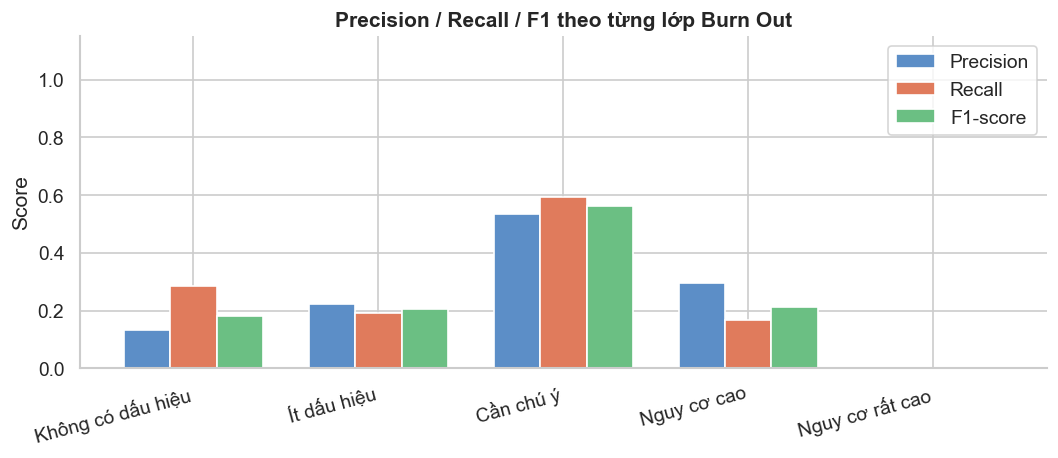

In [37]:
classes_present = sorted(y_test.unique())
target_names    = [BURNOUT_LABEL.get(c, str(c)) for c in classes_present]

print('📋 CLASSIFICATION REPORT — Best Model:\n')
print(classification_report(
    y_test, y_pred_best,
    labels=classes_present,
    target_names=target_names
))

metrics_df = pd.DataFrame({
    'Lớp Burn Out': target_names,
    'Precision': precision_score(y_test, y_pred_best, labels=classes_present,
                                 average=None, zero_division=0).round(3),
    'Recall'   : recall_score(y_test, y_pred_best, labels=classes_present,
                              average=None, zero_division=0).round(3),
    'F1-score' : f1_score(y_test, y_pred_best, labels=classes_present,
                          average=None, zero_division=0).round(3),
    'Support'  : [int((y_test == c).sum()) for c in classes_present],
})
print('📊 Chi tiết per-class metrics:')
display(metrics_df)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(target_names))
w = 0.25
ax.bar(x - w, metrics_df['Precision'], w, label='Precision', color='#5C8EC7', edgecolor='white')
ax.bar(x,     metrics_df['Recall'],    w, label='Recall',    color='#E07B5C', edgecolor='white')
ax.bar(x + w, metrics_df['F1-score'],  w, label='F1-score',  color='#6BBF83', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 theo từng lớp Burn Out', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/16_perclass_metrics.png', bbox_inches='tight')
plt.show()

### Task 9: Confusion Matrix

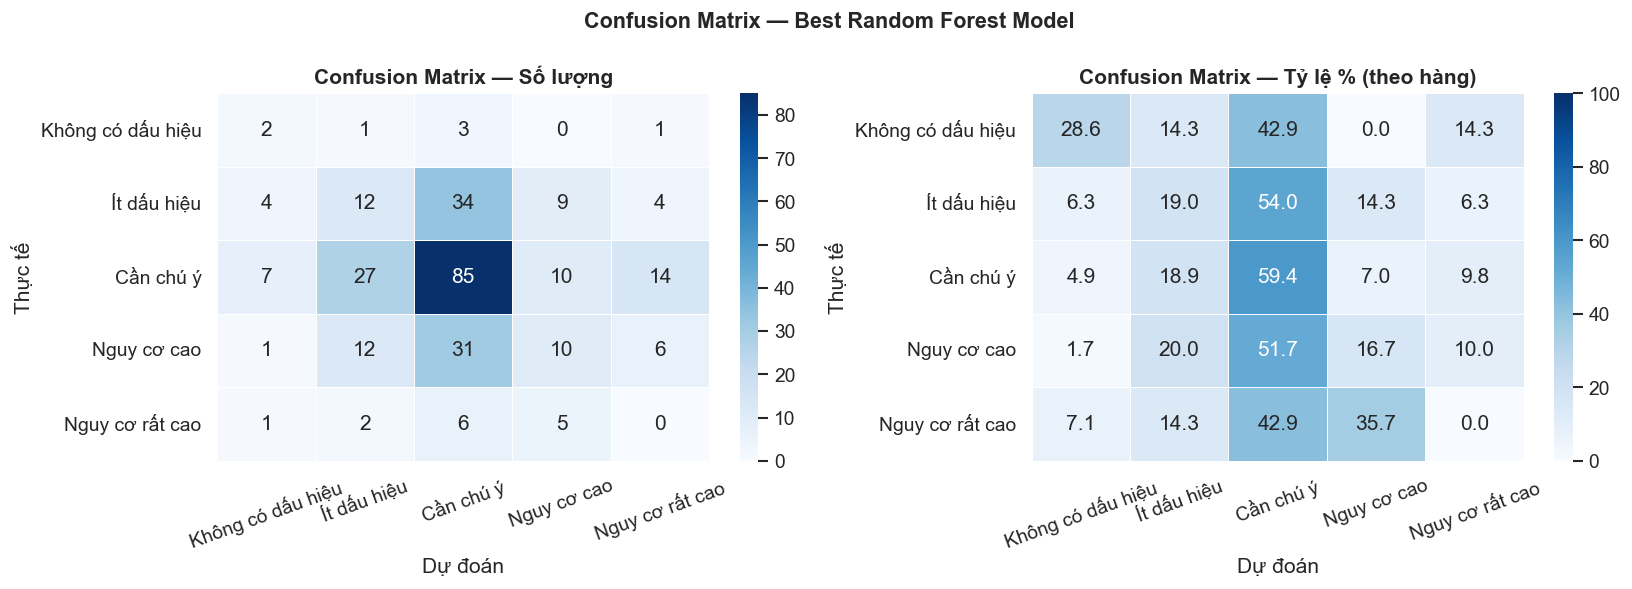


📖 Kết quả trên đường chéo (dự đoán đúng):
   Lớp "Không có dấu hiệu": đúng 2/7 (28.6%)
   Lớp "Ít dấu hiệu": đúng 12/63 (19.0%)
   Lớp "Cần chú ý": đúng 85/143 (59.4%)
   Lớp "Nguy cơ cao": đúng 10/60 (16.7%)
   Lớp "Nguy cơ rất cao": đúng 0/14 (0.0%)


In [38]:
cm = confusion_matrix(y_test, y_pred_best, labels=classes_present)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix — Số lượng', fontweight='bold')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')
axes[0].tick_params(axis='x', rotation=20)

cm_pct = cm.astype(float) / np.where(cm.sum(axis=1, keepdims=True) == 0, 1,
                                      cm.sum(axis=1, keepdims=True)) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=100, ax=axes[1])
axes[1].set_title('Confusion Matrix — Tỷ lệ % (theo hàng)', fontweight='bold')
axes[1].set_xlabel('Dự đoán')
axes[1].set_ylabel('Thực tế')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrix — Best Random Forest Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/17_confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\n📖 Kết quả trên đường chéo (dự đoán đúng):')
for i, lbl in enumerate(target_names):
    correct = cm[i, i]
    total   = cm[i].sum()
    pct     = correct / total * 100 if total > 0 else 0
    print(f'   Lớp "{lbl}": đúng {correct}/{total} ({pct:.1f}%)')

### Task 10:  Feature Importance

- Yếu tố nào ảnh hưởng nhiều nhất đến dự đoán burnout.

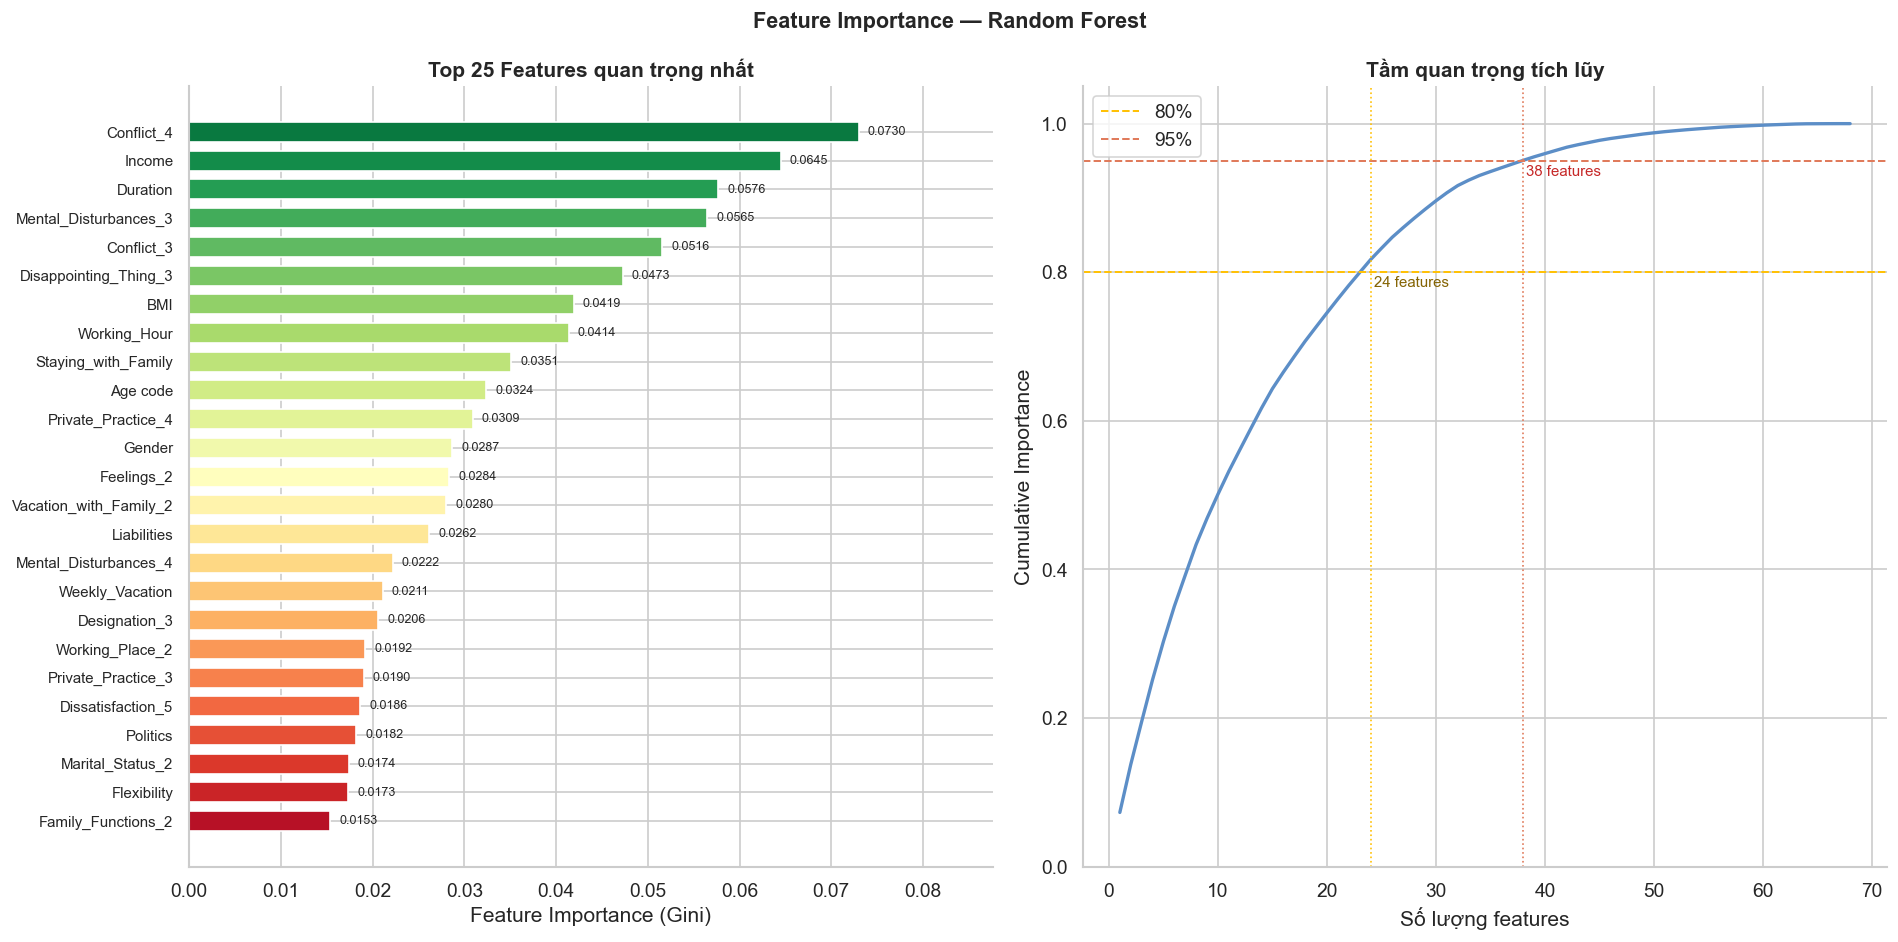


📊 Top 10 features quan trọng nhất:
    1. Conflict_4                            : 0.0730 (7.30%)
    2. Income                                : 0.0645 (6.45%)
    3. Duration                              : 0.0576 (5.76%)
    4. Mental_Disturbances_3                 : 0.0565 (5.65%)
    5. Conflict_3                            : 0.0516 (5.16%)
    6. Disappointing_Thing_3                 : 0.0473 (4.73%)
    7. BMI                                   : 0.0419 (4.19%)
    8. Working_Hour                          : 0.0414 (4.14%)
    9. Staying_with_Family                   : 0.0351 (3.51%)
   10. Age code                              : 0.0324 (3.24%)


In [39]:
importances = pd.Series(
    rf_best.feature_importances_,
    index=kept_cols
).sort_values(ascending=False)

top_n        = min(25, len(importances))
top_features = importances.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

palette = sns.color_palette('RdYlGn_r', top_n)
axes[0].barh(range(top_n), top_features.values[::-1],
             color=palette[::-1], edgecolor='white', height=0.7)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_features.index[::-1], fontsize=9)
for i, val in enumerate(top_features.values[::-1]):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=7.5)
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title(f'Top {top_n} Features quan trọng nhất', fontweight='bold')
axes[0].set_xlim(0, top_features.max() * 1.2)

cumsum    = importances.cumsum()
n_for_80  = int((cumsum < 0.80).sum()) + 1
n_for_95  = int((cumsum < 0.95).sum()) + 1
axes[1].plot(range(1, len(importances)+1), cumsum.values, color='#5C8EC7', linewidth=2)
axes[1].axhline(0.80, color='#FFC107', linestyle='--', linewidth=1.2, label='80%')
axes[1].axhline(0.95, color='#E07B5C', linestyle='--', linewidth=1.2, label='95%')
axes[1].axvline(n_for_80, color='#FFC107', linestyle=':', linewidth=1)
axes[1].axvline(n_for_95, color='#E07B5C', linestyle=':', linewidth=1)
axes[1].text(n_for_80+0.3, 0.78, f'{n_for_80} features', color='#856404', fontsize=9)
axes[1].text(n_for_95+0.3, 0.93, f'{n_for_95} features', color='#C62828', fontsize=9)
axes[1].set_xlabel('Số lượng features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Tầm quan trọng tích lũy', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.suptitle('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/18_feature_importance.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Top 10 features quan trọng nhất:')
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f'   {i:2d}. {feat:<38}: {imp:.4f} ({imp*100:.2f}%)')

### Task 11: Learning Curve

- Chẩn đoán cuối: Model có còn overfit sau khi đã xử lý không?

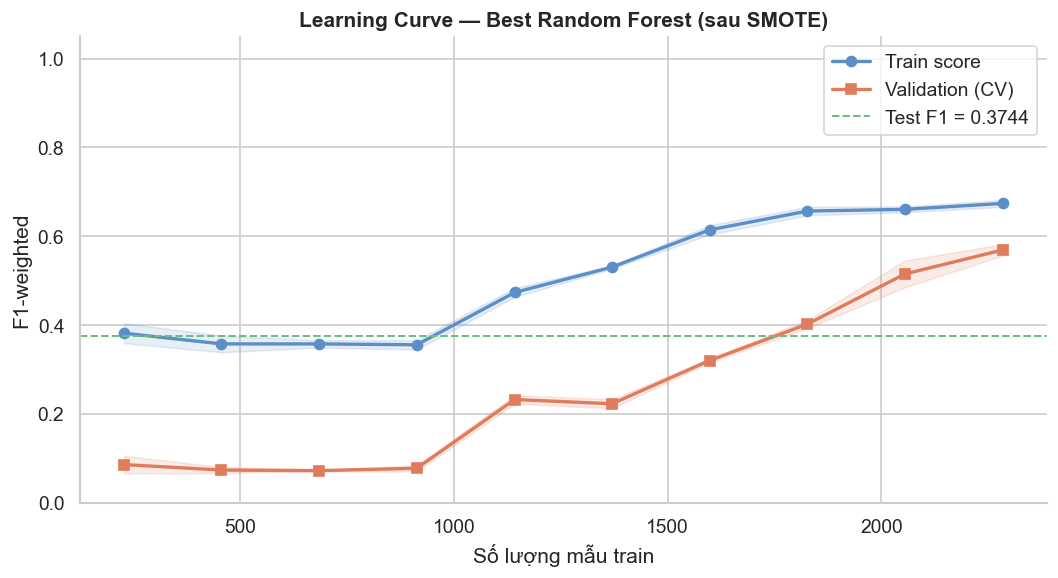


🔍 Chẩn đoán Learning Curve:
   Train score cuối  : 0.6738
   Val score cuối    : 0.5691
   Gap (train - val) : 0.1047 ⚠️  Còn overfit nhẹ
   → Dataset y tế có noise tự nhiên, gap 0.10–0.20 là chấp nhận được.
   → Ghi chú trong phần Hạn chế của báo cáo khóa luận.


In [40]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train_sel, y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#5C8EC7', linewidth=2, label='Train score')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color='#5C8EC7')
ax.plot(train_sizes, val_mean, 's-', color='#E07B5C', linewidth=2, label='Validation (CV)')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.15, color='#E07B5C')
ax.axhline(f1_best, color='#6BBF83', linestyle='--', linewidth=1.2,
           label=f'Test F1 = {f1_best:.4f}')
ax.set_xlabel('Số lượng mẫu train')
ax.set_ylabel('F1-weighted')
ax.set_title('Learning Curve — Best Random Forest (sau SMOTE)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/19_learning_curve.png', bbox_inches='tight')
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
print(f'\n🔍 Chẩn đoán Learning Curve:')
print(f'   Train score cuối  : {train_mean[-1]:.4f}')
print(f'   Val score cuối    : {val_mean[-1]:.4f}')
print(f'   Gap (train - val) : {final_gap:.4f}', end=' ')
if final_gap > 0.10:
    print('⚠️  Còn overfit nhẹ')
    print('   → Dataset y tế có noise tự nhiên, gap 0.10–0.20 là chấp nhận được.')
    print('   → Ghi chú trong phần Hạn chế của báo cáo khóa luận.')
else:
    print('✅ Tốt — không có dấu hiệu overfit nghiêm trọng.')

### Task 12:  Lưu model và toàn bộ config

In [41]:
MODEL_PATH = f'{MODELS_DIR}/rf_model.pkl'
joblib.dump(rf_best,  MODEL_PATH)
joblib.dump(selector, f'{MODELS_DIR}/variance_selector.pkl')

def to_serializable(v):
    if isinstance(v, (np.integer,)):  return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

config = {
    'version'                 : 'v2_smote_featsel',
    'best_params'             : {k: to_serializable(v) for k, v in grid_search.best_params_.items()},
    'cv_best_score'           : round(float(grid_search.best_score_), 4),
    'test_accuracy'           : round(float(acc_best), 4),
    'test_f1_weighted'        : round(float(f1_best), 4),
    'gap_cv_test'             : round(float(gap_best), 4),
    'smote_k_neighbors'       : int(k_neighbors),
    'variance_threshold'      : 0.01,
    'n_features_original'     : int(X_train.shape[1]),
    'n_features_selected'     : int(len(kept_cols)),
    'kept_features'           : kept_cols,
    'dropped_features'        : dropped_cols,
    'classes'                 : [int(c) for c in sorted(y_train.unique())],
    'train_size_before_smote' : int(len(y_train)),
    'train_size_after_smote'  : int(len(y_train_sm)),
    'test_size'               : int(len(y_test)),
}
with open(f'{MODELS_DIR}/rf_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

pd.DataFrame({'feature': importances.index, 'importance': importances.values})\
  .to_csv(f'{MODELS_DIR}/feature_importance.csv', index=False)

print('✅ Đã lưu tất cả file vào models/:\n')
for fname in sorted(os.listdir(MODELS_DIR)):
    fsize = os.path.getsize(os.path.join(MODELS_DIR, fname))
    print(f'   {fname:<35} {fsize:>12,} bytes')

assert (joblib.load(MODEL_PATH).predict(X_test_sel) == y_pred_best).all()
print('\n✅ Kiểm tra load lại model → kết quả khớp hoàn toàn.')

✅ Đã lưu tất cả file vào models/:

   feature_importance.csv                     2,612 bytes
   rf_config.json                             2,757 bytes
   rf_model.pkl                           3,472,289 bytes
   variance_selector.pkl                      2,935 bytes

✅ Kiểm tra load lại model → kết quả khớp hoàn toàn.


### Task 13: Tổng kết

In [ ]:
print('=' * 65)
print('      TỔNG KẾT XÂY DỰNG MÔ HÌNH RANDOM FOREST (v2)')
print('=' * 65)
print(f"""
✅ [1] SMOTE — cân bằng lớp
       Train trước : {len(y_train):,} mẫu  →  Sau : {len(y_train_sm):,} mẫu
       k_neighbors : {k_neighbors}

✅ [2] Feature Selection — loại cột sparse
       {X_train.shape[1]} features  →  {len(kept_cols)} features (loại {len(dropped_cols)} cột)
       Loại: {dropped_cols}

✅ [3] GridSearchCV ({total_combinations} tổ hợp × 5 folds)
       Best CV F1  : {grid_search.best_score_:.4f}
       Best params : {grid_search.best_params_}

✅ [4] Kết quả Best Model (test set)
       Accuracy    : {acc_best:.4f} ({acc_best*100:.2f}%)
       F1-weighted : {f1_best:.4f}
       Gap CV/test : {gap_best:.4f}  {'✅ OK' if gap_best <= 0.10 else '⚠️  Còn overfit nhẹ (chấp nhận được)'}

✅ [5] 7 biểu đồ đã lưu vào reports/figures/
       (13 → 19: SMOTE, Variance, GridSearch, Metrics, CM, FI, LC)

✅ [6] 4 file đã lưu vào models/
       rf_model.pkl | rf_config.json
       variance_selector.pkl | feature_importance.csv
""")

      TỔNG KẾT XÂY DỰNG MÔ HÌNH RANDOM FOREST (v2)

✅ [1] SMOTE — cân bằng lớp
       Train trước : 1,147 mẫu  →  Sau : 2,855 mẫu
       k_neighbors : 5

✅ [2] Feature Selection — loại cột sparse
       86 features  →  68 features (loại 18 cột)
       Loại: ['Designation_6', 'Designation_10', 'Designation_12', 'Specialization_7', 'Specialization_12', 'Specialization_13', 'Specialization_18', 'Working_Place_3', 'Marital_Status_3', 'Marital_Status_4', 'Disappointing_Thing_6', 'Disappointing_Thing_8', 'Feelings_4', 'Feelings_6', 'Dissatisfaction_8', 'Mental_Disturbances_6', 'Mental_Disturbances_8', 'Mental_Disturbances_9']

✅ [3] GridSearchCV (72 tổ hợp × 5 folds)
       Best CV F1  : 0.5691
       Best params : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 20, 'n_estimators': 300}

✅ [4] Kết quả Best Model (test set)
       Accuracy    : 0.3798 (37.98%)
       F1-weighted : 0.3744
       Gap CV/test : 0.1947  ⚠️  Còn overfit nhẹ (chấp nhận được)

✅ 